In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LinearRegression
plt.style.use("ggplot")

In [4]:
emp=pd.read_csv("employed.csv")
emp.columns=emp.columns.str.strip()
emp.head(10)

,iso_code,country,sex,age,year,obs_value
0,AFG,Afghanistan,Total,15+,2025,32.457
1,AFG,Afghanistan,Total,15-24,2025,31.419
2,AFG,Afghanistan,Total,25+,2025,33.056
3,AFG,Afghanistan,Male,15+,2025,61.038
4,AFG,Afghanistan,Male,15-24,2025,57.355
5,AFG,Afghanistan,Male,25+,2025,63.243
6,AFG,Afghanistan,Female,15+,2025,3.815
7,AFG,Afghanistan,Female,15-24,2025,4.235
8,AFG,Afghanistan,Female,25+,2025,3.580
9,AFG,Afghanistan,Total,15+,2024,32.408


In [5]:
unemp=pd.read_csv("unemployed.csv")
unemp.columns=unemp.columns.str.strip()
unemp.head(10)

,iso_code,country,sex,age,year,obs_value
0,AFG,Afghanistan,Total,15+,2025,13.351
1,AFG,Afghanistan,Total,15-24,2025,16.785
2,AFG,Afghanistan,Total,25+,2025,11.340
3,AFG,Afghanistan,Male,15+,2025,12.503
4,AFG,Afghanistan,Male,15-24,2025,15.814
5,AFG,Afghanistan,Male,25+,2025,10.594
6,AFG,Afghanistan,Female,15+,2025,24.996
7,AFG,Afghanistan,Female,15-24,2025,28.496
8,AFG,Afghanistan,Female,25+,2025,22.493
9,AFG,Afghanistan,Total,15+,2024,13.687


In [6]:
emp=emp.rename(columns={"obs_value":"Employment"})


In [7]:
unemp=unemp.rename(columns={"obs_value":"Unemployment"})

In [8]:
emp=emp[(emp["sex"]=="Total") & (emp["age"]=="15+")]
unemp=unemp[(unemp["sex"]=="Total") & (unemp["age"]=="15+")]

In [9]:
df=pd.merge(emp[["iso_code","country","year","Employment"]],
           unemp[["iso_code","country","year","Unemployment"]],
           on=["iso_code","country","year"],
           how="inner")

In [42]:
# print(unemp.columns)

Index(['iso_code', 'country', 'sex', 'age', 'year', 'Unemployment'], dtype='object')


In [10]:
global_trend=df.groupby("year")[["Employment","Unemployment"]].mean()

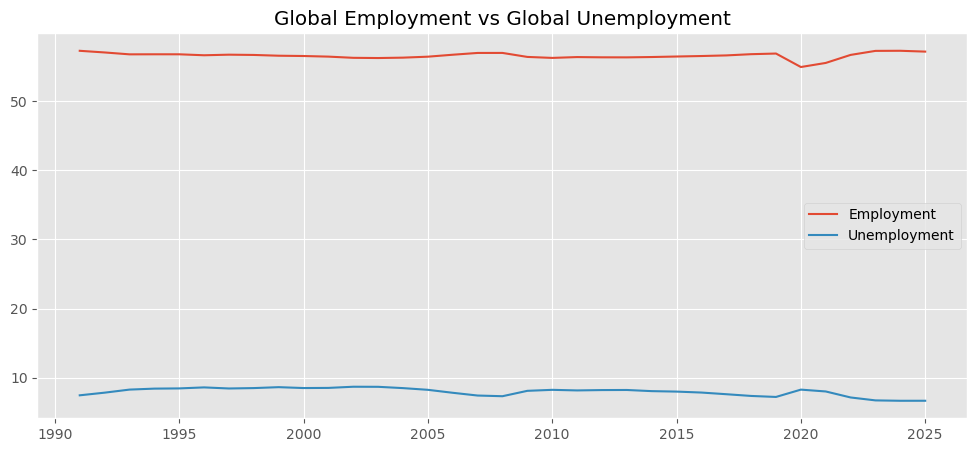

In [45]:
plt.figure(figsize=(12,5))
plt.plot(global_trend.index,global_trend["Employment"],label="Employment")
plt.plot(global_trend.index,global_trend["Unemployment"],label="Unemployment")
plt.legend()
plt.title("Global Employment vs Global Unemployment")
plt.show()

In [47]:
latest_year=df["year"].max()
latest=df[df["year"]==latest_year]
top_unemp=latest.sort_values("Unemployment",ascending=False).head(10)

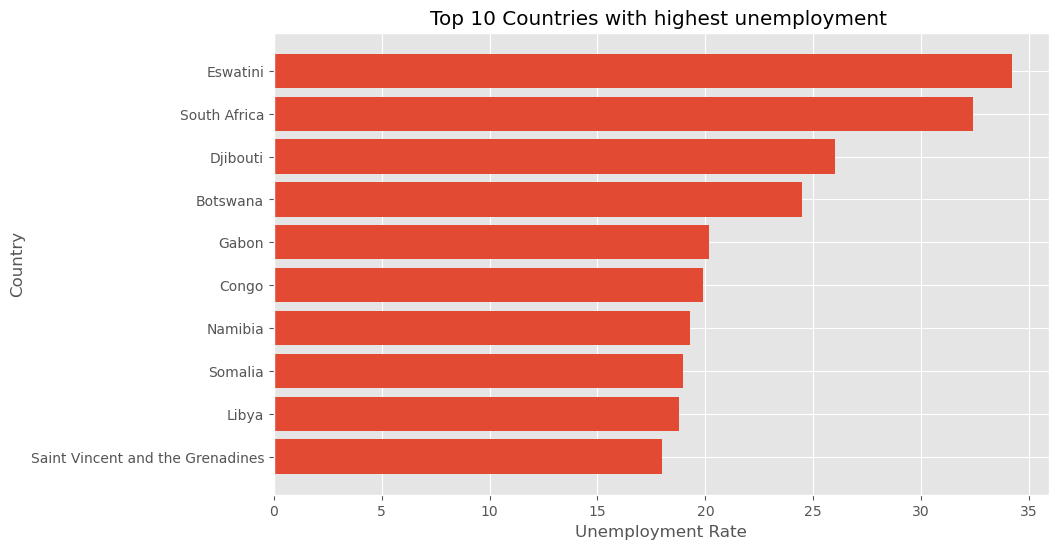

In [49]:
plt.figure(figsize=(10,6))
plt.barh(top_unemp["country"],top_unemp["Unemployment"])

plt.xlabel("Unemployment Rate")
plt.ylabel("Country")
plt.title("Top 10 Countries with highest unemployment ")
plt.gca().invert_yaxis()
plt.show()

In [50]:
countries=df["country"].unique()[:5]

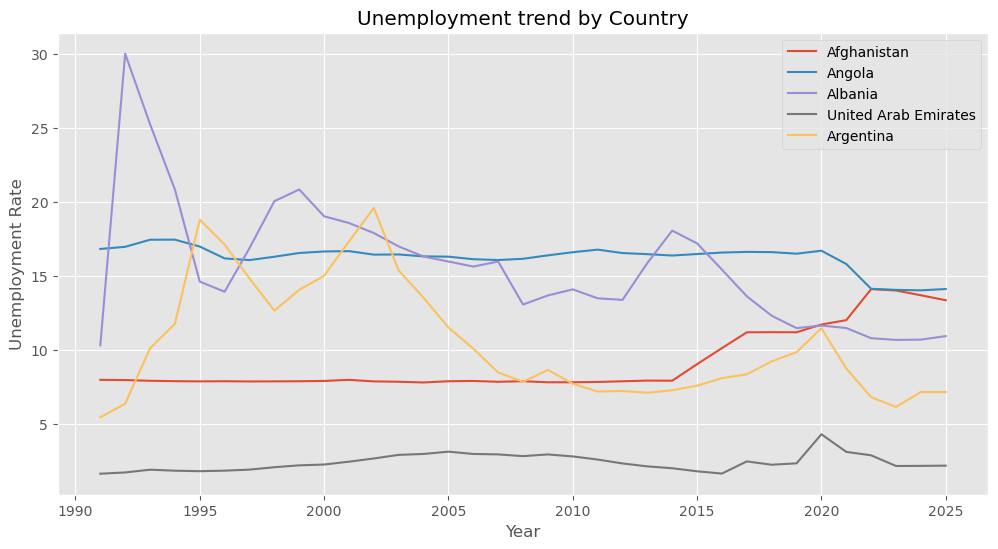

In [52]:
plt.figure(figsize=(12,6))

for c in countries:
    temp=df[df["country"]==c]
    plt.plot(temp["year"],temp["Unemployment"],label=c)
plt.legend()
plt.title("Unemployment trend by Country")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate")
plt.show()

<Axes: xlabel='Employment', ylabel='Unemployment'>

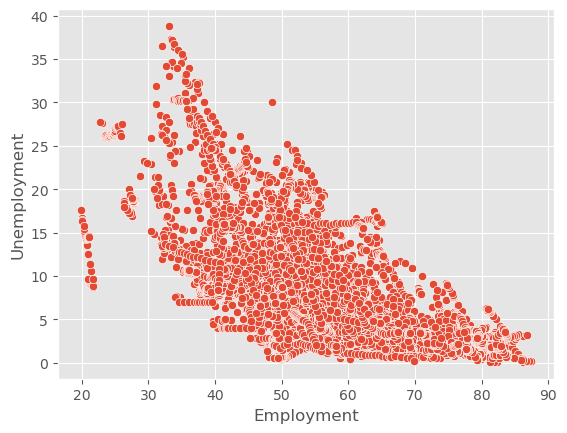

In [54]:
sns.scatterplot(x=df["Employment"],y=df["Unemployment"])

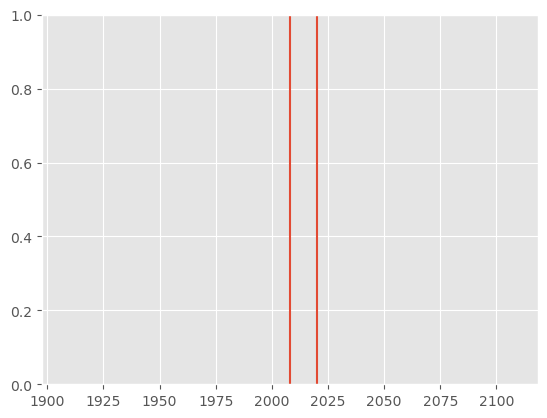

In [56]:
plt.axvline(2008)
plt.axvline(2020)

In [57]:
df["country"].unique()

array(['Afghanistan', 'Angola', 'Albania', 'United Arab Emirates',
       'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan',
       'Burundi', 'Belgium', 'Benin', 'Burkina Faso', 'Bangladesh',
       'Bulgaria', 'Bahrain', 'Bahamas', 'Bosnia and Herzegovina',
       'Belarus', 'Belize', 'Bolivia (Plurinational State of)', 'Brazil',
       'Barbados', 'Brunei Darussalam', 'Bhutan', 'Botswana',
       'Central African Republic', 'Canada', 'Switzerland', 'Chile',
       'China', "Côte d'Ivoire", 'Cameroon',
       'Congo, Democratic Republic of the', 'Congo', 'Colombia',
       'Comoros', 'Cabo Verde', 'Costa Rica', 'Cuba', 'Cyprus', 'Czechia',
       'Germany', 'Djibouti', 'Denmark', 'Dominican Republic', 'Algeria',
       'Ecuador', 'Egypt', 'Eritrea', 'Western Sahara', 'Spain',
       'Estonia', 'Ethiopia', 'Finland', 'Fiji', 'France', 'Gabon',
       'United Kingdom of Great Britain and Northern Ireland', 'Georgia',
       'Ghana', 'Guinea', 'Gambia', 'Guinea-Bissau', 'Equa

In [58]:
india=df[df["country"]=="India"]

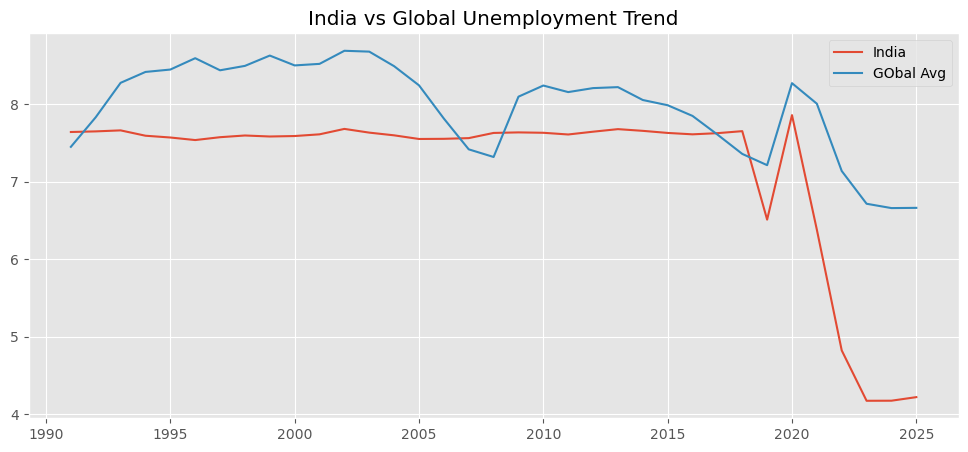

In [59]:
plt.figure(figsize=(12,5))
plt.plot(india["year"],india["Unemployment"],label="India")
plt.plot(global_trend.index,global_trend["Unemployment"],label="GObal Avg")
plt.legend()
plt.title("India vs Global Unemployment Trend")
plt.show()

<Axes: xlabel='year', ylabel='country'>

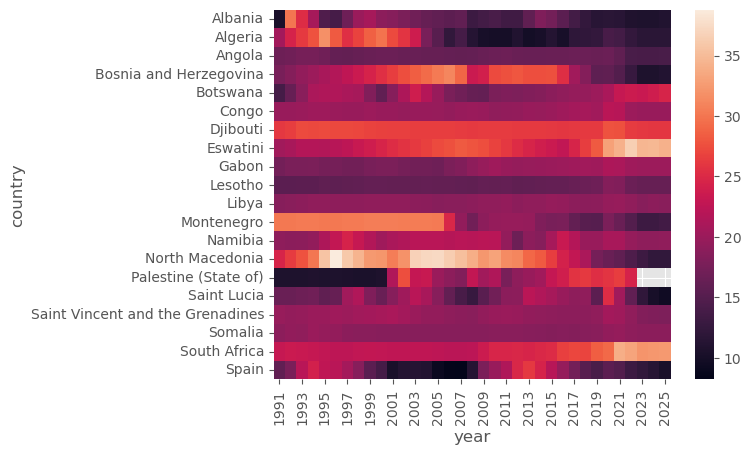

In [62]:
top20=df.groupby("country")["Unemployment"].mean().sort_values(ascending=False).head(20)
pivot=df[df["country"].isin(top20.index)].pivot(index="country",columns="year",values="Unemployment")
sns.heatmap(pivot)

In [63]:
ranking=df.groupby("country")["Unemployment"].mean().sort_values(ascending=False)
ranking.loc["India"]

np.float64(7.180571428571429)

In [ ]:
# pre 2008 baseline

In [64]:
pre_crisis=df[(df["year"]>=2005) & (df["year"]<=2007)]
baseline=pre_crisis.groupby("country")["Unemployment"].mean()

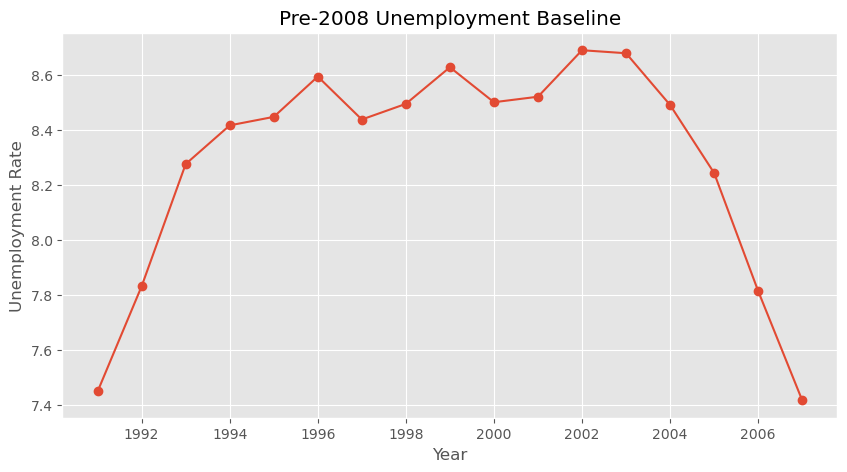

In [19]:
plt.figure(figsize=(10,5))

pre_2008 = df[df["year"] < 2008].groupby("year")["Unemployment"].mean()
plt.plot(pre_2008.index, pre_2008.values, marker='o')

plt.title("Pre-2008 Unemployment Baseline")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate")

plt.show()

In [ ]:
# 2008 crisis peak

In [65]:
crisis=df[(df["year"]>=2008) & (df["year"]<=2010)]
peak=crisis.groupby("country")["Employment"].max()

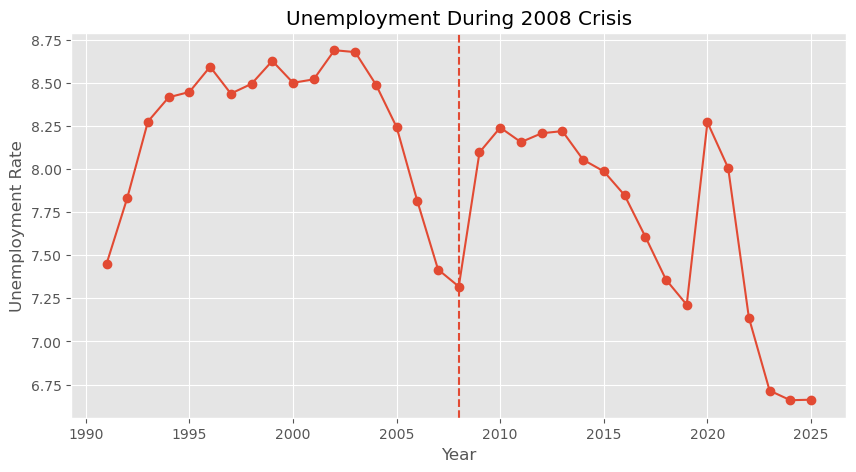

In [20]:
plt.figure(figsize=(10,5))

crisis = df.groupby("year")["Unemployment"].mean()
plt.plot(crisis.index, crisis.values, marker='o')

plt.axvline(2008, linestyle='--')

plt.title("Unemployment During 2008 Crisis")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate")

plt.show()

In [ ]:
# recovery year

In [66]:
recovery_year={}
for c in baseline.index:
    base=baseline.loc[c]
    temp=df[df["country"]==c]
    rec=temp[temp["Unemployment"]<=base]
    if not rec.empty:
        recovery_year[c]=rec["year"].min()

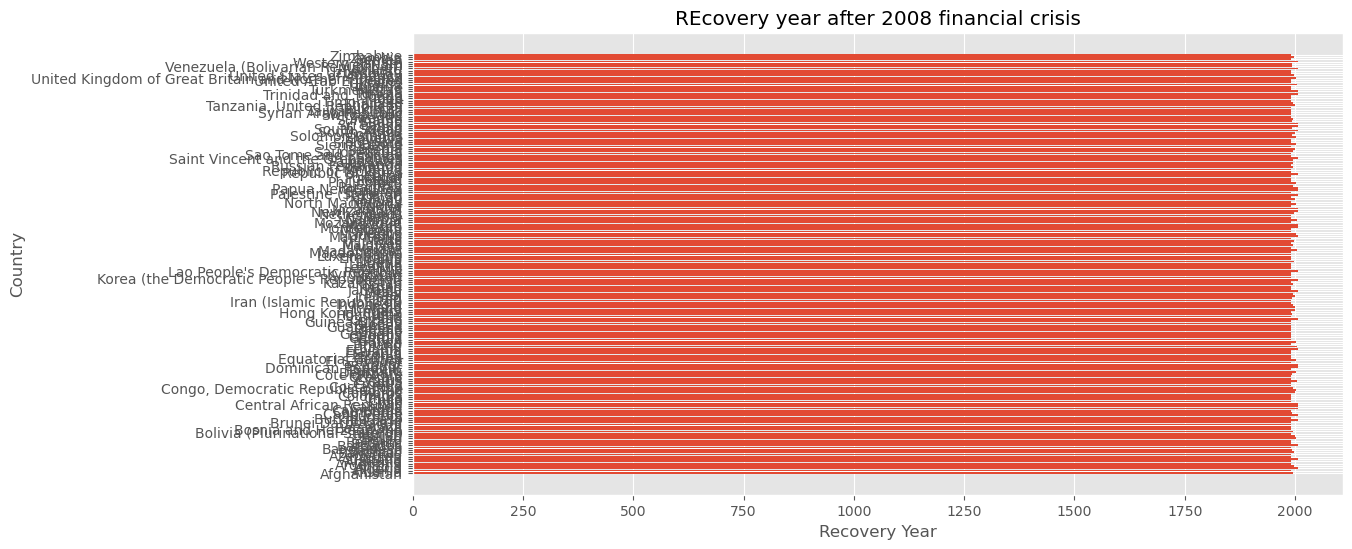

In [67]:
countries=list(recovery_year.keys())
years=list(recovery_year.values())

plt.figure(figsize=(12,6))
plt.barh(countries,years)
plt.xlabel("Recovery Year")
plt.ylabel("Country")
plt.title("REcovery year after 2008 financial crisis")
plt.show()

In [ ]:
# Pre-Covid Baseline

In [11]:
pre_covid=df[(df["year"]>=2017) & (df["year"]<=2019)]
baseline_covid=pre_covid.groupby("country")["Unemployment"].mean()

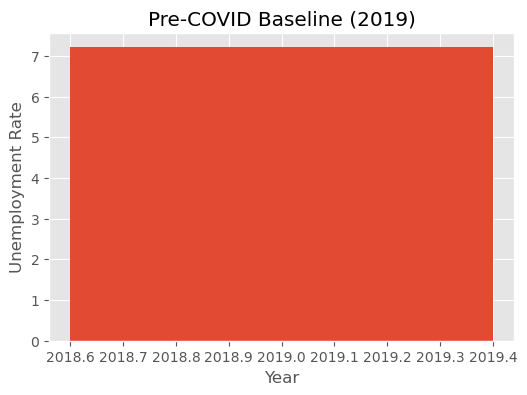

In [21]:
plt.figure(figsize=(6,4))

pre_covid = df[df["year"] == 2019].groupby("year")["Unemployment"].mean()
plt.bar(pre_covid.index, pre_covid.values)

plt.title("Pre-COVID Baseline (2019)")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate")

plt.show()

In [ ]:
# covid peak

In [12]:
covid=df[(df["year"]>=2020) & df["year"]<2021]
peak_covid=covid.groupby("country")["Unemployment"].max()

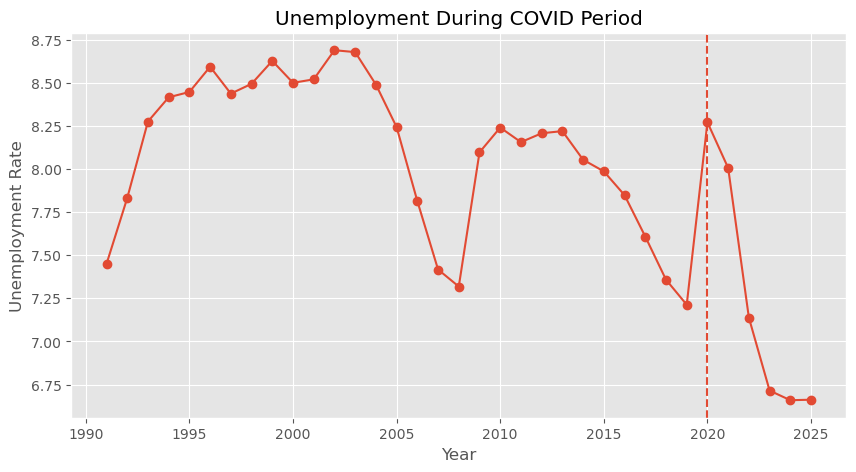

In [22]:
plt.figure(figsize=(10,5))

covid = df.groupby("year")["Unemployment"].mean()
plt.plot(covid.index, covid.values, marker='o')

plt.axvline(2020, linestyle='--')

plt.title("Unemployment During COVID Period")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate")

plt.show()

In [13]:
# Covid Recovery YEar
covid_recovery_year = {}

for c in baseline_covid.index:
    base = baseline_covid.loc[c]
    
    temp = df[(df["country"] == c) & (df["year"] >= 2020)]
    
    rec = temp[temp["Unemployment"] <= base]
    
    if not rec.empty:
        covid_recovery_year[c] = rec["year"].min()

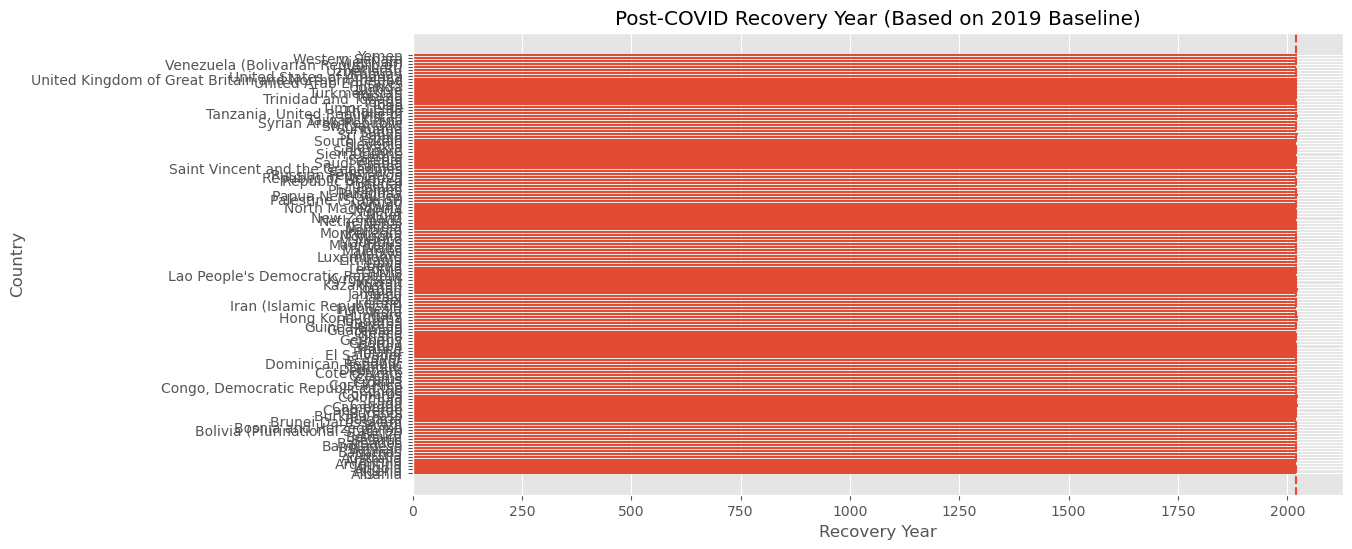

In [14]:
countries = list(covid_recovery_year.keys())
years = list(covid_recovery_year.values())

plt.figure(figsize=(12,6))
plt.barh(countries, years)

# Add reference line for COVID year
plt.axvline(2020, linestyle='--')

plt.xlabel("Recovery Year")
plt.ylabel("Country")
plt.title("Post-COVID Recovery Year (Based on 2019 Baseline)")

plt.show()

In [15]:
# Did employment increse or decrease over time for most countries

In [16]:
# Calculate trend for each country
trend = {}

for c in df["country"].unique():
    temp = df[df["country"] == c].sort_values("year")
    start = temp["Unemployment"].iloc[0]   # first year value
    end = temp["Unemployment"].iloc[-1]    # last year value
    if end > start:
        trend[c] = "Increased"
    elif end < start:
        trend[c] = "Decreased"
    else:
        trend[c] = "No Change"

# Convert to DataFrame for better view
trend_df = pd.DataFrame(list(trend.items()), columns=["Country", "Trend"])

# Count how many increased/decreased
trend_summary = trend_df["Trend"].value_counts()
print(trend_df)
print("\nSummary:\n", trend_summary)

                  Country      Trend
0             Afghanistan  Increased
1                  Angola  Decreased
2                 Albania  Increased
3    United Arab Emirates  Increased
4               Argentina  Increased
..                    ...        ...
178                 Samoa  Increased
179                 Yemen  Increased
180          South Africa  Increased
181                Zambia  Decreased
182              Zimbabwe  Increased

[183 rows x 2 columns]

Summary:
 Trend
Decreased    98
Increased    84
No Change     1
Name: count, dtype: int64


In [17]:
# identify spikes or drops in unemployment 

In [18]:
# Calculate year-to-year change
df["change"] = df.groupby("country")["Unemployment"].diff()
# Define threshold for spike/drop (you can adjust)
threshold = 2
# Find spikes
spikes = df[df["change"] > threshold]
# Find drops
drops = df[df["change"] < -threshold]
print("Spikes:\n", spikes[["country", "year", "change"]])
print("\nDrops:\n", drops[["country", "year", "change"]])

Spikes:
         country  year  change
88      Albania  2007   2.906
101     Albania  1994   6.228
102     Albania  1993   4.416
103     Albania  1992   4.756
145   Argentina  2020   2.725
...         ...   ...     ...
6336     Zambia  2010   2.642
6339     Zambia  2007   2.629
6340     Zambia  2006   2.670
6341     Zambia  2005   2.671
6350     Zambia  1996   2.027

[179 rows x 3 columns]

Drops:
            country  year  change
4      Afghanistan  2021  -2.094
82         Albania  2013  -2.189
83         Albania  2012  -2.490
98         Albania  1997  -3.170
99         Albania  1996  -2.944
...            ...   ...     ...
6230         Samoa  2011  -3.072
6262         Yemen  2014  -4.433
6291  South Africa  2020  -4.790
6337        Zambia  2009  -2.607
6338        Zambia  2008  -2.653

[216 rows x 3 columns]
